# Task 4 — Regression Adjustment ABC

**Reference:** Beaumont, Zhang & Balding (2002), *Approximate Bayesian Computation in Population Genetics*.

## Idea

Basic rejection ABC accepts samples whose simulated summaries $s_i$ are close to the observed $s_\text{obs}$, but there is always a residual gap $s_i - s_\text{obs}$.  
Regression adjustment corrects for this gap post-hoc:

For each parameter $\theta_j$, fit a **weighted local linear regression**:
$$\theta_j = \alpha_j + \boldsymbol{\beta}_j^\top (s_i - s_\text{obs}) + \varepsilon_i,
\qquad w_i = K\!\left(\frac{d_i}{h}\right)$$
where $K$ is the Epanechnikov kernel and $h$ is the ABC bandwidth.  
The **adjusted sample** is the residual shifted to $s_\text{obs}$:
$$\theta_j^* = \theta_j - \boldsymbol{\beta}_j^\top (s_i - s_\text{obs}) = \hat{\alpha}_j + \hat{\varepsilon}_i$$

This lets us use a **looser tolerance** (more accepted samples, less variance) while still getting a sharp posterior.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT / "scripts"))

## 1. Load Data

In [2]:
# ── Observed data ─────────────────────────────────────────────────────────────
def load_observed(data_dir: Path):
    inf_df = pd.read_csv(data_dir / "infected_timeseries.csv")
    rew_df = pd.read_csv(data_dir / "rewiring_timeseries.csv")
    deg_df = pd.read_csv(data_dir / "final_degree_histograms.csv")
    obs_inf = inf_df.pivot(index="replicate_id", columns="time",   values="infected_fraction").sort_index().values.astype(float)
    obs_rew = rew_df.pivot(index="replicate_id", columns="time",   values="rewire_count").sort_index().values.astype(float)
    obs_deg = deg_df.pivot(index="replicate_id", columns="degree", values="count").sort_index().values.astype(float)
    return obs_inf, obs_rew, obs_deg

obs_inf, obs_rew, obs_deg = load_observed(ROOT / "data")

# ── Prior simulations ─────────────────────────────────────────────────────────
raw     = np.load(ROOT / "data" / "prior_simulations.npz")
thetas  = raw["thetas"]                            # (M, 3)
sim_inf = raw["infected_fractions"]                # (M, R, 201)
sim_rew = raw["rewire_counts"].astype(float)       # (M, R, 201)
sim_deg = raw["degree_histograms"].astype(float)   # (M, R, 31)
M, R    = sim_inf.shape[:2]

PRIOR_LOW  = np.array([0.05, 0.02, 0.0])
PRIOR_HIGH = np.array([0.50, 0.20, 0.8])
PARAM_NAMES = [r"$\beta$", r"$\gamma$", r"$\rho$"]
print(f"Loaded {M:,} draws × {R} replicates")

Loaded 10,000 draws × 40 replicates


## 2. Summary Statistics

Reuse the same feature catalogue from `rejection_abc.ipynb`.  
Change `ACTIVE_SET` to test different summary choices.

In [3]:
DEGREES = np.arange(31, dtype=float)

def _degree_mean(deg):
    total = deg.sum(axis=2, keepdims=True).clip(min=1)
    return ((deg * DEGREES).sum(axis=2, keepdims=True) / total).mean(axis=1)

def _degree_std(deg):
    total = deg.sum(axis=2, keepdims=True).clip(min=1)
    mu  = (deg * DEGREES).sum(axis=2) / total.squeeze(2)
    mu2 = (deg * DEGREES**2).sum(axis=2) / total.squeeze(2)
    return np.sqrt((mu2 - mu**2).clip(min=0)).mean(axis=1, keepdims=True)

FEATURE_FUNCS = {
    "peak_inf":          lambda i, w, d: np.max(i, axis=2).mean(axis=1, keepdims=True),
    "time_to_peak_inf":  lambda i, w, d: np.argmax(i, axis=2).astype(float).mean(axis=1, keepdims=True),
    "final_inf":         lambda i, w, d: i[:, :, -1].mean(axis=1, keepdims=True),
    "total_inf":         lambda i, w, d: i.sum(axis=2).mean(axis=1, keepdims=True),
    "std_peak_inf":      lambda i, w, d: np.max(i, axis=2).std(axis=1, keepdims=True),
    "inf_ts20":          lambda i, w, d: i[:, :, np.linspace(0, i.shape[2]-1, 20, dtype=int)].mean(axis=1),
    "total_rew":         lambda i, w, d: w.sum(axis=2).mean(axis=1, keepdims=True),
    "peak_rew":          lambda i, w, d: np.max(w, axis=2).mean(axis=1, keepdims=True),
    "time_to_peak_rew":  lambda i, w, d: np.argmax(w, axis=2).astype(float).mean(axis=1, keepdims=True),
    "rew_ts20":          lambda i, w, d: w[:, :, np.linspace(0, w.shape[2]-1, 20, dtype=int)].mean(axis=1),
    "mean_degree":       lambda i, w, d: _degree_mean(d),
    "std_degree":        lambda i, w, d: _degree_std(d),
    "isolated_frac":     lambda i, w, d: (d[:, :, 0] / d.sum(axis=2).clip(min=1)).mean(axis=1, keepdims=True),
    "high_degree_frac":  lambda i, w, d: (d[:, :, 20:].sum(axis=2) / d.sum(axis=2).clip(min=1)).mean(axis=1, keepdims=True),
}

SUMMARY_SETS = {
    "infection_only": ["peak_inf", "time_to_peak_inf", "final_inf", "total_inf"],
    "rewiring_only":  ["total_rew", "peak_rew", "time_to_peak_rew"],
    "degree_only":    ["mean_degree", "std_degree", "isolated_frac", "high_degree_frac"],
    "all_scalar":     ["peak_inf", "time_to_peak_inf", "final_inf", "total_inf", "std_peak_inf",
                       "total_rew", "peak_rew", "time_to_peak_rew",
                       "mean_degree", "std_degree", "isolated_frac", "high_degree_frac"],
    "all":            ["inf_ts20", "std_peak_inf", "rew_ts20",
                       "mean_degree", "std_degree", "isolated_frac", "high_degree_frac"],
}

# ── Change this to experiment ─────────────────────────────────────────────────
ACTIVE_SET = "all"

def compute_summaries(inf, rew, deg, feature_set=None):
    feature_set = feature_set or ACTIVE_SET
    squeeze = inf.ndim == 2
    if squeeze:
        inf, rew, deg = inf[np.newaxis], rew[np.newaxis], deg[np.newaxis]
    rew, deg = rew.astype(float), deg.astype(float)
    parts = []
    for name in SUMMARY_SETS[feature_set]:
        feat = FEATURE_FUNCS[name](inf, rew, deg)
        parts.append(feat[:, np.newaxis] if feat.ndim == 1 else feat)
    result = np.concatenate(parts, axis=1)
    return result[0] if squeeze else result

sim_stats = compute_summaries(sim_inf, sim_rew, sim_deg)   # (M, n_features)
obs_stats = compute_summaries(obs_inf, obs_rew, obs_deg)   # (n_features,)
print(f"Summary matrix: {sim_stats.shape}  |  observed vector: {obs_stats.shape}")

Summary matrix: (10000, 45)  |  observed vector: (45,)


## 3. Regression Adjustment

Implementation of Beaumont et al. (2002).  
`ABC_QUANTILE` controls how many samples to keep **before** adjustment.  
With regression you can afford a looser tolerance — try `0.05` or even `0.10`.

In [4]:
# ── Config ────────────────────────────────────────────────────────────────────
ABC_QUANTILE = 0.05   # acceptance rate before regression (can be loose)

# ── Step 1: Standardise summaries ─────────────────────────────────────────────
scaler    = StandardScaler()
sim_sc    = scaler.fit_transform(sim_stats)      # (M, F)
obs_sc    = scaler.transform(obs_stats[None])[0] # (F,)

# ── Step 2: Compute distances & accept ────────────────────────────────────────
delta     = sim_sc - obs_sc                      # (M, F)  deviation from observed
dists     = np.linalg.norm(delta, axis=1)        # (M,)
h         = np.quantile(dists, ABC_QUANTILE)     # bandwidth = ε
mask      = dists <= h

theta_acc = thetas[mask]                         # (n_acc, 3)
delta_acc = delta[mask]                          # (n_acc, F)  s_i - s_obs
dists_acc = dists[mask]                          # (n_acc,)

print(f"Bandwidth h = {h:.4f}  |  accepted {mask.sum():,} / {M:,} ({ABC_QUANTILE:.0%})")

# ── Step 3: Epanechnikov kernel weights ───────────────────────────────────────
u       = dists_acc / h                          # normalised distances in [0,1]
weights = (3/4) * (1 - u**2)                     # Epanechnikov kernel
weights = weights / weights.sum()                # normalise

# ── Step 4: Weighted least-squares regression for each parameter ──────────────
# Model: θ_j = α_j + β_j · (s_i - s_obs) + ε_i
# WLS via sqrt(w)-scaling: multiply both sides by sqrt(w)
sw        = np.sqrt(weights)                     # (n_acc,)
X         = np.column_stack([np.ones(len(delta_acc)), delta_acc])  # (n_acc, F+1)
Xw        = X * sw[:, None]                      # weighted design matrix
Yw        = theta_acc * sw[:, None]              # weighted targets (n_acc, 3)

# Solve for each parameter via lstsq
coefs, _, _, _ = np.linalg.lstsq(Xw, Yw, rcond=None)  # (F+1, 3)
intercepts = coefs[0]          # α_j for j=0,1,2
slopes     = coefs[1:]         # β_j (F, 3)

# ── Step 5: Adjusted samples ──────────────────────────────────────────────────
# θ*_j = θ_j - β_j · (s_i - s_obs)  =  residual + intercept
correction    = delta_acc @ slopes               # (n_acc, 3)
theta_adj     = theta_acc - correction           # (n_acc, 3)

print(f"Regression coef matrix shape: {coefs.shape}")
print(f"Adjusted sample shape: {theta_adj.shape}")

Bandwidth h = 1.4503  |  accepted 500 / 10,000 (5%)
Regression coef matrix shape: (46, 3)
Adjusted sample shape: (500, 3)


## 4. Compare Raw vs. Adjusted Posteriors

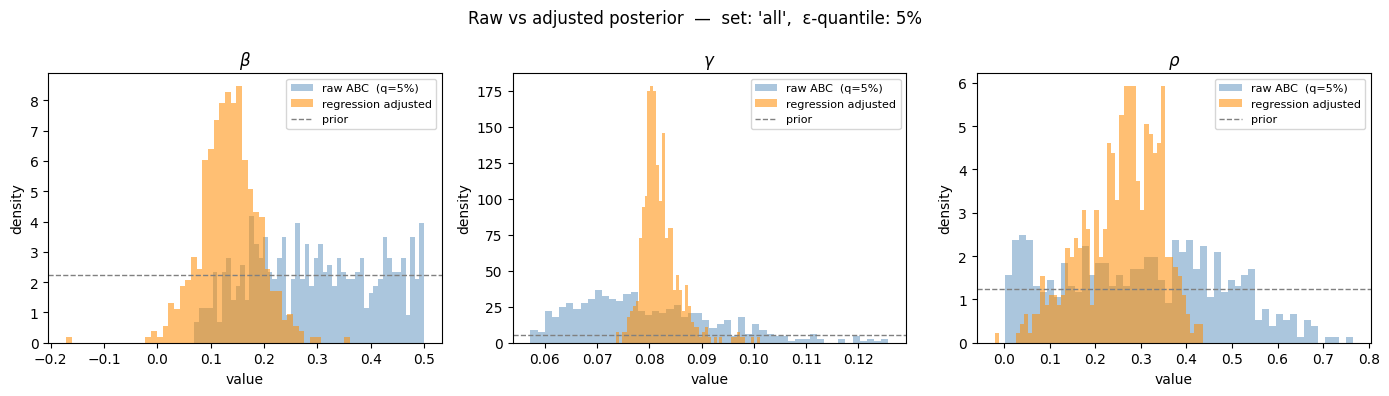

In [5]:
BINS = 50
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, j, name in zip(axes, range(3), PARAM_NAMES):
    ax.hist(theta_acc[:, j], bins=BINS, density=True, alpha=0.45,
            color="steelblue", label=f"raw ABC  (q={ABC_QUANTILE:.0%})")
    ax.hist(theta_adj[:, j], bins=BINS, density=True, alpha=0.55,
            color="darkorange", label="regression adjusted")
    ax.axhline(1 / (PRIOR_HIGH[j] - PRIOR_LOW[j]), color="grey",
               ls="--", lw=1, label="prior")
    ax.set(title=name, xlabel="value", ylabel="density")
    ax.legend(fontsize=8)
plt.suptitle(f"Raw vs adjusted posterior  —  set: '{ACTIVE_SET}',  ε-quantile: {ABC_QUANTILE:.0%}")
plt.tight_layout()

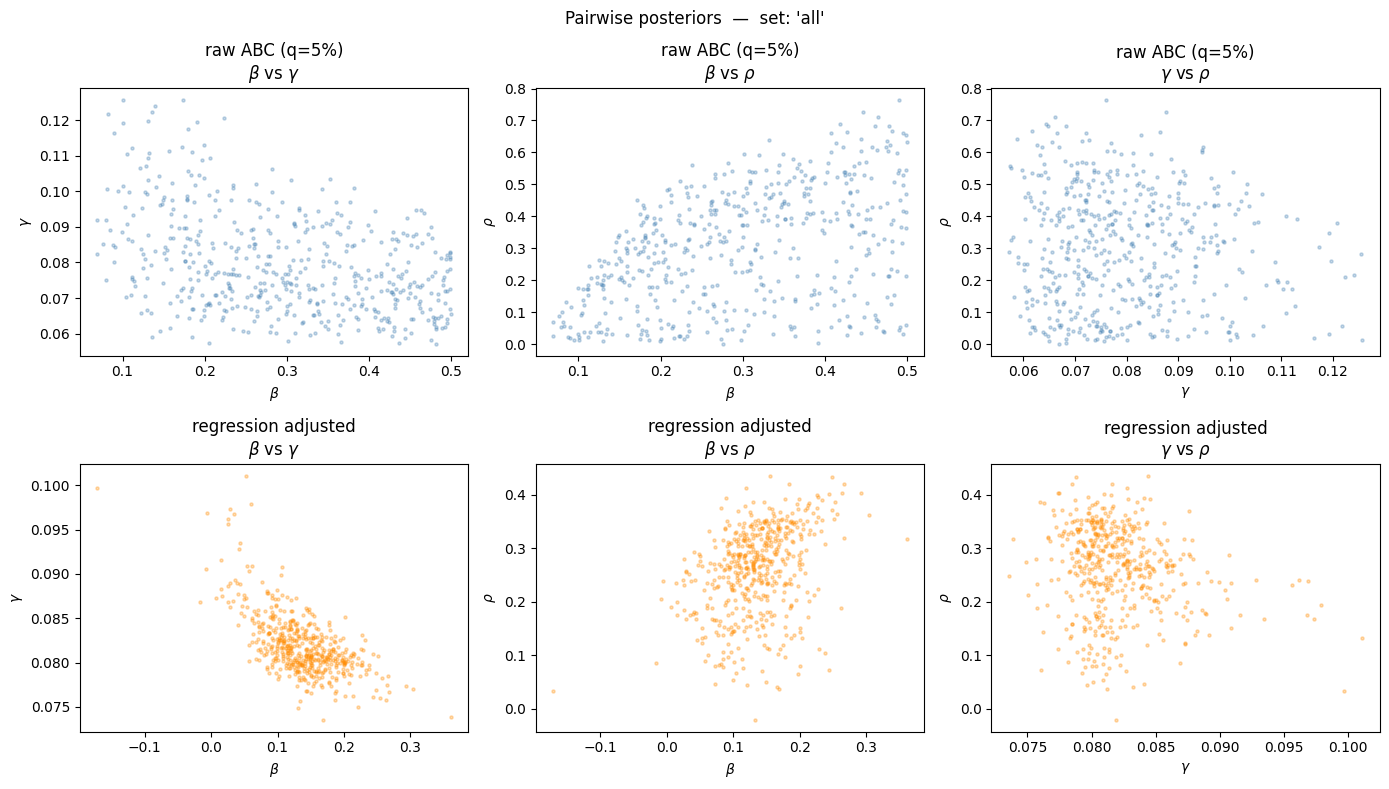

In [6]:
# ── Pairwise scatter: raw vs adjusted ────────────────────────────────────────
pairs       = [(0, 1), (0, 2), (1, 2)]
pair_labels = [(r"$\beta$", r"$\gamma$"), (r"$\beta$", r"$\rho$"), (r"$\gamma$", r"$\rho$")]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for col, (i, j), (xi, xj) in zip(range(3), pairs, pair_labels):
    for row, (theta, label, color) in enumerate([
        (theta_acc, f"raw ABC (q={ABC_QUANTILE:.0%})", "steelblue"),
        (theta_adj, "regression adjusted",             "darkorange"),
    ]):
        ax = axes[row, col]
        ax.scatter(theta[:, i], theta[:, j], s=5, alpha=0.3, color=color, rasterized=True)
        ax.set(xlabel=xi, ylabel=xj, title=f"{label}\n{xi} vs {xj}")
plt.suptitle(f"Pairwise posteriors  —  set: '{ACTIVE_SET}'")
plt.tight_layout()

## 5. Sensitivity to Tolerance

A key advantage of regression adjustment: the posterior should be similar across a range of tolerances.  
If it is, the regression correction is working well.  If results change a lot, try a tighter tolerance.

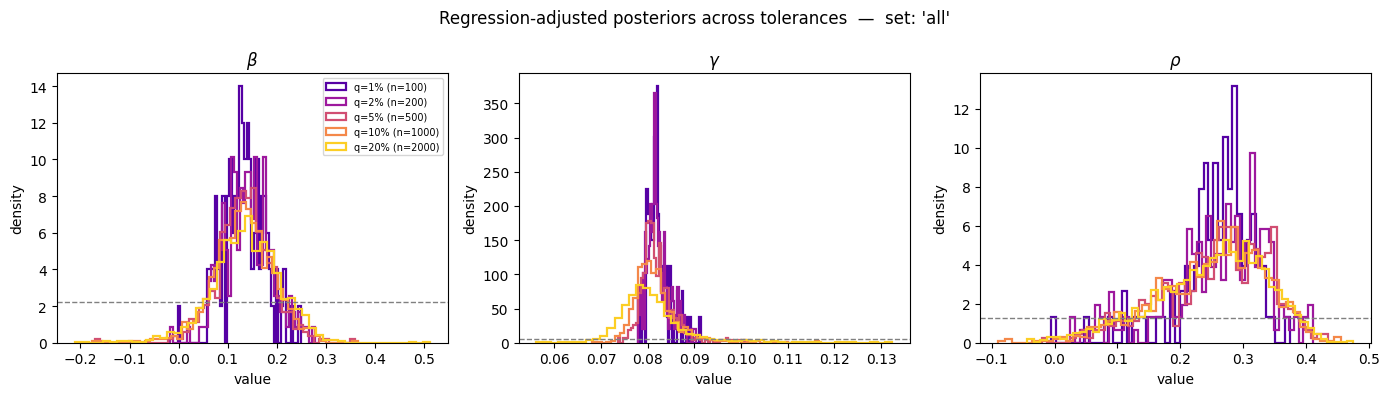

In [7]:
QUANTILES = [0.01, 0.02, 0.05, 0.10, 0.20]
q_colors  = plt.cm.plasma(np.linspace(0.15, 0.9, len(QUANTILES)))

def regression_adjust(quantile, feature_set=None):
    """Run full regression adjustment pipeline and return adjusted thetas."""
    s_sim = compute_summaries(sim_inf, sim_rew, sim_deg, feature_set=feature_set)
    s_obs = compute_summaries(obs_inf, obs_rew, obs_deg, feature_set=feature_set)
    sc    = StandardScaler()
    s_sim_sc = sc.fit_transform(s_sim)
    s_obs_sc = sc.transform(s_obs[None])[0]
    dlt   = s_sim_sc - s_obs_sc
    d     = np.linalg.norm(dlt, axis=1)
    h_    = np.quantile(d, quantile)
    msk   = d <= h_
    th    = thetas[msk]
    dl    = dlt[msk]
    u_    = d[msk] / h_
    w_    = (3/4) * (1 - u_**2)
    w_    = w_ / w_.sum()
    sw_   = np.sqrt(w_)
    X_    = np.column_stack([np.ones(len(dl)), dl]) * sw_[:, None]
    Y_    = th * sw_[:, None]
    c_, *_ = np.linalg.lstsq(X_, Y_, rcond=None)
    return th - dl @ c_[1:], th   # adjusted, raw

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, j, name in zip(axes, range(3), PARAM_NAMES):
    for color, q in zip(q_colors, QUANTILES):
        adj, _ = regression_adjust(q)
        ax.hist(adj[:, j], bins=50, density=True, histtype="step",
                linewidth=1.6, color=color, label=f"q={q:.0%} (n={len(adj)})")
    ax.axhline(1 / (PRIOR_HIGH[j] - PRIOR_LOW[j]), color="grey", ls="--", lw=1)
    ax.set(title=name, xlabel="value", ylabel="density")
axes[0].legend(fontsize=7)
plt.suptitle(f"Regression-adjusted posteriors across tolerances  —  set: '{ACTIVE_SET}'")
plt.tight_layout()

## 6. Sensitivity to Summary Set

Compare regression-adjusted posteriors across all defined summary sets at a fixed tolerance.

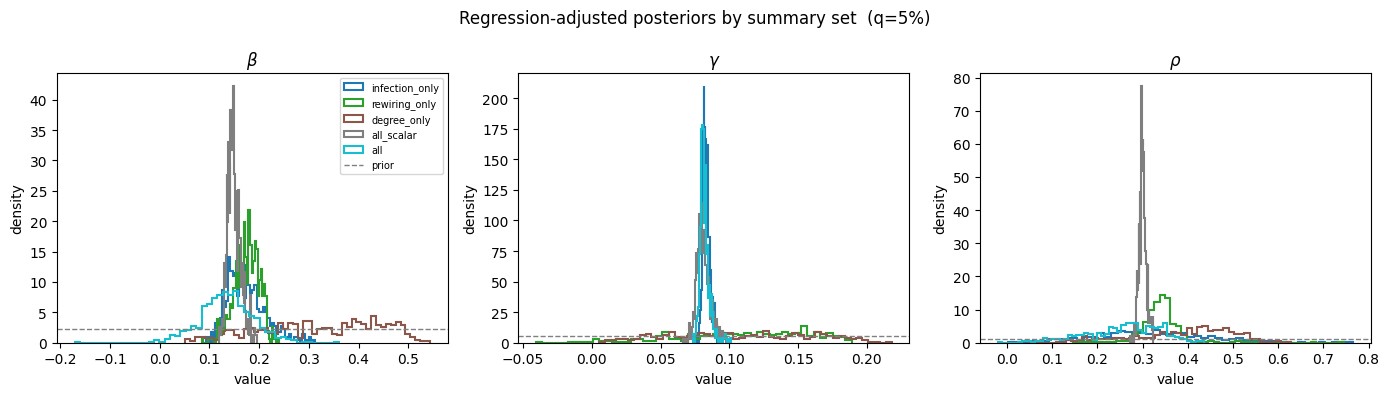

In [8]:
FIXED_Q  = 0.05
colors   = plt.cm.tab10(np.linspace(0, 1, len(SUMMARY_SETS)))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, j, name in zip(axes, range(3), PARAM_NAMES):
    for color, sname in zip(colors, SUMMARY_SETS):
        adj, _ = regression_adjust(FIXED_Q, feature_set=sname)
        ax.hist(adj[:, j], bins=50, density=True, histtype="step",
                linewidth=1.5, color=color, label=sname)
    ax.axhline(1 / (PRIOR_HIGH[j] - PRIOR_LOW[j]), color="grey", ls="--", lw=1, label="prior")
    ax.set(title=name, xlabel="value", ylabel="density")
axes[0].legend(fontsize=7)
plt.suptitle(f"Regression-adjusted posteriors by summary set  (q={FIXED_Q:.0%})")
plt.tight_layout()

## 7. Posterior Width: Raw ABC vs Regression Adjustment

For each summary set and a range of tolerances, compare the posterior std of raw vs adjusted samples.  
Regression adjustment should give tighter (or equal) posteriors especially at loose tolerances.

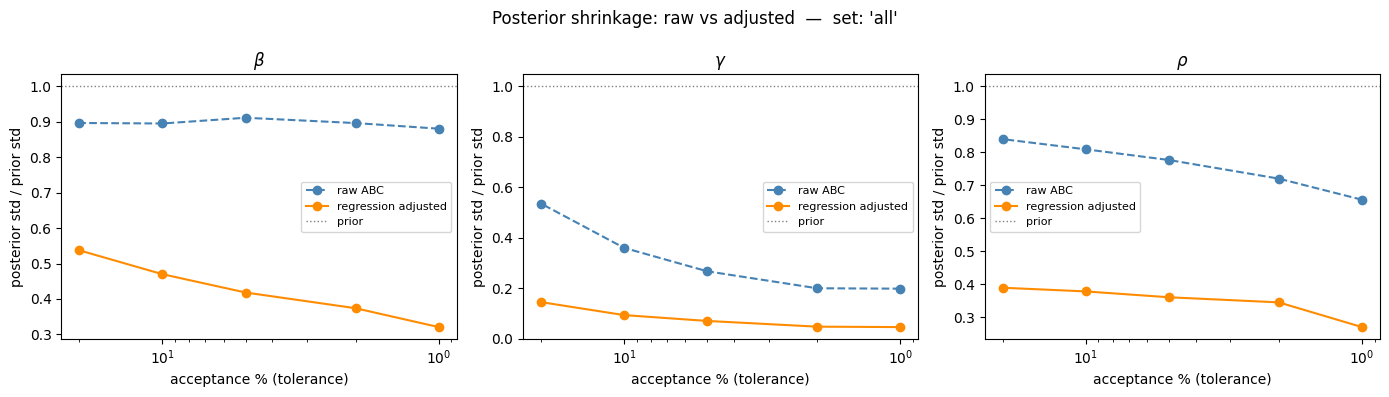

In [9]:
COMPARE_SET = "all"   # ← summary set to compare
QUANTILES_W = [0.01, 0.02, 0.05, 0.10, 0.20]

prior_std = (PRIOR_HIGH - PRIOR_LOW) / np.sqrt(12)

raw_stds = []
adj_stds = []
for q in QUANTILES_W:
    adj, raw = regression_adjust(q, feature_set=COMPARE_SET)
    raw_stds.append(raw.std(axis=0) / prior_std)
    adj_stds.append(adj.std(axis=0) / prior_std)

raw_stds = np.array(raw_stds)   # (n_q, 3)
adj_stds = np.array(adj_stds)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
x = [q * 100 for q in QUANTILES_W]
for ax, j, name in zip(axes, range(3), PARAM_NAMES):
    ax.plot(x, raw_stds[:, j], "o--", color="steelblue",   label="raw ABC")
    ax.plot(x, adj_stds[:, j], "o-",  color="darkorange",  label="regression adjusted")
    ax.axhline(1.0, color="grey", ls=":", lw=1, label="prior")
    ax.set(title=name, xlabel="acceptance % (tolerance)",
           ylabel="posterior std / prior std", xscale="log")
    ax.invert_xaxis()
    ax.legend(fontsize=8)
plt.suptitle(f"Posterior shrinkage: raw vs adjusted  —  set: '{COMPARE_SET}'")
plt.tight_layout()

## 8. Posterior Summary Table

In [10]:
adj_final, raw_final = regression_adjust(ABC_QUANTILE)

rows = []
for label, samples in [(f"raw ABC (q={ABC_QUANTILE:.0%})", raw_final),
                        (f"regression adjusted (q={ABC_QUANTILE:.0%})", adj_final)]:
    for j, pname in enumerate(["beta", "gamma", "rho"]):
        rows.append({
            "method": label, "param": pname,
            "mean":   samples[:, j].mean(),
            "std":    samples[:, j].std(),
            "q05":    np.quantile(samples[:, j], 0.05),
            "q50":    np.quantile(samples[:, j], 0.50),
            "q95":    np.quantile(samples[:, j], 0.95),
        })

display(pd.DataFrame(rows).set_index(["method", "param"]).round(4))

mean     std     q05     q50     q95
method                     param                                        
raw ABC (q=5%)             beta   0.2962  0.1184  0.1114  0.2923  0.4836
                           gamma  0.0796  0.0139  0.0613  0.0768  0.1047
                           rho    0.3007  0.1794  0.0309  0.3025  0.5949
regression adjusted (q=5%) beta   0.1351  0.0543  0.0465  0.1332  0.2238
                           gamma  0.0820  0.0036  0.0775  0.0813  0.0881
                           rho    0.2580  0.0832  0.0996  0.2693  0.3735